# Import & Helpers

In [1]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from importlib import reload

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
from noninteracting import KagomeNagaosa
import interaction
import frg_kernel
import channels
import frg_flow
import patching
from patching import build_exactM_patchset, PatchPoint, PatchSet, plot_patchset, exact_M6_points_1bz

## Plot Helper

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels
import instability
import frg_flow
import interaction
import frg_kernel

from channels import SZ0ChannelBuilder
from instability import InstabilityConfig, diagnose_kernel_collection
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from frg_kernel import FlowConfig


# ============================================================
# Basic formatting / plotting helpers
# ============================================================

CHANNELS_ORDER = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    """
    Same logic as current solver sign-aware score:
      pp -> largest positive eigenvalue of Hermitian part
      ph -> absolute value of most negative eigenvalue of Hermitian part
    """
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals)) if evals.size else 0.0
    eval_neg_min = float(np.min(evals)) if evals.size else 0.0

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def build_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return channels.SZ0ChannelBuilder.from_solver(
        solver.current_vertex_accessor(),
        solver,
        Landau_F=Landau_F,
    )


def evaluate_signaware_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)
        kernel_store[iq] = {"Q": Q.copy(), "kernels": kernel_dict}

        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })

    df = pd.DataFrame(rows)
    return df, kernel_store


def evaluate_instability_selected_Qs(
    builder,
    solver,
    diagnosis_Qs,
    *,
    temperature=None,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    rows = []
    result_store = {}

    if temperature is None:
        temperature = float(solver.state.T)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # IMPORTANT: keep diagnosis consistent with current flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": Q.copy(), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store


def leading_row_from_df(df, score_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(score_col, ascending=False).iloc[0]


def plot_channel_bars(df, *, value_col, title, ylabel):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(CHANNELS_ORDER):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0][value_col]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Flow Helper

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Helpers: dataframe shaping / printing / plotting
# ============================================================

def _is_q0_vec(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return bool(np.allclose(q, 0.0, atol=tol, rtol=0.0))


def _scores_at_qindex(df, q_index, value_col, channels_order=CHANNELS_ORDER):
    sub = df[df["Q_index"] == int(q_index)]
    out = {}
    for ch in channels_order:
        ss = sub[sub["channel"] == ch]
        out[ch] = float(ss.iloc[0][value_col]) if len(ss) else np.nan
    return out


def _leading_row(df, value_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(value_col, ascending=False).iloc[0]


def _format_channel_scores(score_map, channels_order=CHANNELS_ORDER):
    parts = []
    for ch in channels_order:
        val = score_map.get(ch, np.nan)
        if np.isfinite(val):
            parts.append(f"{ch}={val:.3e}")
        else:
            parts.append(f"{ch}=nan")
    return ", ".join(parts)


def _append_step_rows(storage, df, *, step_index, T, family):
    for _, row in df.iterrows():
        storage.append({
            "family": family,  # "kernel" or "instability"
            "step_index": int(step_index),
            "T": float(T),
            "Q_index": int(row["Q_index"]),
            "Q": np.asarray(row["Q"], dtype=float),
            "Qx": float(row["Qx"]),
            "Qy": float(row["Qy"]),
            "channel": str(row["channel"]),
            "value": float(row["physical_score"] if family == "kernel" else row["score"]),
        })


def _collapse_q_groups(history_df, *, q0_tol=1e-10):
    """
    Collapse selected Qs into two groups:
      - Q0 : exact q=0
      - QM : max over all nonzero selected Q's
    """
    rows = []
    for (family, step_index, T, channel), sub in history_df.groupby(["family", "step_index", "T", "channel"]):
        sub = sub.copy()
        q0_mask = sub["Q"].apply(lambda x: _is_q0_vec(x, tol=q0_tol)).values

        # Q=0
        sub_q0 = sub[q0_mask]
        q0_val = np.nan
        if len(sub_q0):
            q0_val = float(np.max(sub_q0["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "Q0",
            "value": q0_val,
        })

        # Q=M group = max over all nonzero chosen Qs
        sub_qm = sub[~q0_mask]
        qm_val = np.nan
        if len(sub_qm):
            qm_val = float(np.max(sub_qm["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "QM",
            "value": qm_val,
        })

    out = pd.DataFrame(rows).sort_values(["family", "Q_group", "step_index", "channel"]).reset_index(drop=True)
    return out


def plot_flow_group_curves(
    grouped_df,
    *,
    last_n_steps=None,
    ylog=True,
    title_prefix="RG flow",
    ylim=1e-2
):
    """
    Produce exactly 4 plots:
      1. Q=0 kernel score vs T
      2. Q=M kernel score vs T
      3. Q=0 instability score vs T
      4. Q=M instability score vs T
    """
    df = grouped_df.copy()

    if last_n_steps is not None:
        keep_steps = sorted(df["step_index"].unique())[-int(last_n_steps):]
        df = df[df["step_index"].isin(keep_steps)].copy()

    panels = [
        ("kernel", "Q0", "sign-aware kernel score"),
        ("kernel", "QM", "sign-aware kernel score"),
        ("instability", "Q0", "physical instability score"),
        ("instability", "QM", "physical instability score"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (family, q_group, ylabel) in zip(axes, panels):
        sub = df[(df["family"] == family) & (df["Q_group"] == q_group)].copy()

        for ch in CHANNELS_ORDER:
            ss = sub[sub["channel"] == ch].sort_values("step_index")
            if len(ss) == 0:
                continue

            y = ss["value"].to_numpy(dtype=float)
            x = ss["T"].to_numpy(dtype=float)

            if ylog:
                y = np.where(y > 0, y, np.nan)
                ax.set_yscale("log")

            ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=ch)

        ax.set_title(f"{title_prefix}: {family} / {q_group}")
        ax.set_xlabel("Temperature")
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=ylim)
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def print_flow_step_summary(
    *,
    step_index,
    T,
    rhs_norm,
    signaware_df,
    instab_df,
):
    lead_kernel = _leading_row(signaware_df, "physical_score")
    lead_instab = _leading_row(instab_df, "score")

    lead_qi_kernel = int(lead_kernel["Q_index"])
    lead_qi_instab = int(lead_instab["Q_index"])

    kernel_scores_at_leadQ = _scores_at_qindex(signaware_df, lead_qi_kernel, "physical_score")
    instab_scores_at_leadQ = _scores_at_qindex(instab_df, lead_qi_instab, "score")

    print(
        f"step={step_index:4d} | "
        f"T={T:.6f} | rhs_norm={rhs_norm:.3e} | "
        f"lead_kernel={lead_kernel['channel']} @ Q{lead_qi_kernel}:{fmt_q(lead_kernel['Q'])} "
        f"score={float(lead_kernel['physical_score']):.3e}"
    )
    print("kernel scores:", _format_channel_scores(kernel_scores_at_leadQ))
    print(
        f"    lead_instability={lead_instab['channel']} @ Q{lead_qi_instab}:{fmt_q(lead_instab['Q'])} "
        f"score={float(lead_instab['score']):.3e}"
    )
    print("instability:", _format_channel_scores(instab_scores_at_leadQ))


def run_flow_with_tracking(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    """
    Manual RG flow with per-step diagnostics:
      - sign-aware kernel score
      - physical instability score

    Returns
    -------
    history : list[FlowStepRecord]
    signaware_history_df : pd.DataFrame
    instability_history_df : pd.DataFrame
    grouped_plot_df : pd.DataFrame
    """
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []

    # -------------------------------
    # step 0
    # -------------------------------
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    builder0 = build_builder_from_solver(solver, Landau_F=False)

    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        print("\n[flow stopped at step 0]")
        print("reason:", rec0.instability_reason)
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

    # -------------------------------
    # main loop
    # -------------------------------
    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

def run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []
    snapshots = {}

    # step 0
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    snapshots[0] = make_snapshot_from_solver(solver, label="step_0")

    builder0 = build_builder_from_solver(solver, Landau_F=False)
    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        snapshots[int(rec.step_index)] = make_snapshot_from_solver(
            solver, label=f"step_{rec.step_index}"
        )

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

## Diagnosis Helper

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step selection helpers
# ============================================================
def summarize_eigenvector_against_constant(eigvec):
    v = np.asarray(eigvec, dtype=complex)
    n = len(v)
    v = v / np.linalg.norm(v)

    u_const = np.ones(n, dtype=complex) / np.sqrt(float(n))
    overlap = np.vdot(u_const, v)

    return {
        "eigvec": v,
        "const_vec": u_const,
        "const_overlap_abs": float(np.abs(overlap)),
        "const_overlap_complex": overlap,
    }


def plot_kernel_eigenstate_components(
    kernel_matrix,
    channel_name,
    Q,
    *,
    title_prefix="Kernel eigenstate components",
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)
    info = summarize_eigenvector_against_constant(eigvec)

    v = info["eigvec"]
    u_const = info["const_vec"]
    overlap_abs = info["const_overlap_abs"]

    idx = np.arange(len(v))
    amp = np.abs(v)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # left: Re / Im vs patch index
    axes[0].plot(idx, np.real(v), marker="o", linewidth=1.5, label="Re(v)")
    axes[0].plot(idx, np.imag(v), marker="s", linewidth=1.5, label="Im(v)")
    axes[0].plot(idx, np.real(u_const), linestyle=":", linewidth=1.5, color="black", label="constant vector")
    axes[0].set_xlabel("patch index")
    axes[0].set_ylabel("component")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n"
        f"|<u_const|v>| = {overlap_abs:.6f}"
    )
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # right: |component|
    axes[1].bar(idx, amp)
    axes[1].set_xlabel("patch index")
    axes[1].set_ylabel("|component|")
    axes[1].set_title("Absolute component weight of leading eigenstate")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n=== leader eigenstate summary ===")
    print("channel            :", channel_name)
    print("Q                  :", fmt_q(Q, nd=6))
    print("selected eigenvalue:", f"{eigval:.12e}")
    print("kernel dimension   :", len(v))
    print("|<u_const|v>|      :", f"{overlap_abs:.12e}")

    return eigval, eigvec, info

def resolve_history_step(history, step_selector=-1):
    """
    step_selector:
      - negative int: Python-style indexing from the end
      - nonnegative int: exact step_index lookup if possible, else positional fallback
    """
    if len(history) == 0:
        raise ValueError("History is empty.")

    if isinstance(step_selector, (int, np.integer)):
        step_selector = int(step_selector)

        # negative -> python indexing
        if step_selector < 0:
            rec = history[step_selector]
            return rec

        # first try exact step_index
        for rec in history:
            if int(rec.step_index) == step_selector:
                return rec

        # fallback: positional
        if 0 <= step_selector < len(history):
            return history[step_selector]

    raise ValueError(f"Could not resolve step_selector={step_selector!r}")


# ============================================================
# Snapshot helpers
# ============================================================

from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray


def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )


def make_snapshot_from_history_record(solver, rec, label=None):
    """
    Build a snapshot from the CURRENT solver state only if the solver is already
    sitting at that record's state. This helper is mostly for the last step.

    For arbitrary historical steps, use stored snapshots if you saved them during flow.
    """
    if label is None:
        label = f"step_{rec.step_index}"
    return make_snapshot_from_solver(solver, label=label)


def make_snapshot_accessor(snapshot, solver):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)
    p4_residual = np.asarray(snapshot.p4_residual, dtype=float)

    closure_tol = getattr(solver, "closure_tol", None)
    drop_inexact_closure = bool(getattr(solver, "drop_inexact_closure", False))

    def closure_is_valid(p1, p2, p3):
        if not drop_inexact_closure:
            return True
        if closure_tol is None:
            return True
        return bool(float(p4_residual[p1, p2, p3]) <= float(closure_tol))

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        if not closure_is_valid(p1, p2, p3):
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])

    return accessor


def make_builder_from_snapshot(snapshot, solver, *, Landau_F=False):
    return channels.SZ0ChannelBuilder.from_solver(
        make_snapshot_accessor(snapshot, solver),
        solver,
        Landau_F=Landau_F,
    )


# ============================================================
# Diagnosis on one snapshot
# ============================================================

def diagnose_snapshot_signaware(snapshot, solver, diagnosis_Qs, *, landau_F=False):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)
    df, kernel_store = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=landau_F)
    return df, kernel_store, builder


def diagnose_snapshot_instability(
    snapshot,
    solver,
    diagnosis_Qs,
    *,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # keep consistent with solver flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snapshot.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    rows = []
    result_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=landau_F)

        res_dict = instability.diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": np.asarray(Q, dtype=float), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": np.asarray(Q, dtype=float),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store, builder


# ============================================================
# Eigenvector distribution helpers
# ============================================================

def choose_signaware_eigenpair(channel_name, M):
    H = hermitian_part(M)
    evals, evecs = np.linalg.eigh(H)

    if channel_name.startswith("pp"):
        idx = int(np.argmax(evals))
    elif channel_name.startswith("ph"):
        idx = int(np.argmin(evals))
    else:
        raise ValueError(f"Unknown channel_name={channel_name}")

    val = float(np.real(evals[idx]))
    vec = np.asarray(evecs[:, idx], dtype=complex)
    nrm = np.linalg.norm(vec)
    if nrm > 0:
        vec = vec / nrm
    return val, vec


def plot_kernel_eigenstate_distribution(
    kernel_matrix,
    channel_name,
    Q,
    patchsets,
    *,
    title_prefix="Kernel eigenstate distribution",
    annotate=True,
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)

    ps = patchsets["up"]
    ks = np.asarray([p.k_cart for p in ps.patches], dtype=float)

    amp = np.abs(eigvec)
    phase = np.angle(eigvec)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # amplitude
    sc0 = axes[0].scatter(ks[:, 0], ks[:, 1], c=amp, s=120, cmap="viridis")
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[0].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n|evec|"
    )
    axes[0].set_xlabel(r"$k_x$")
    axes[0].set_ylabel(r"$k_y$")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0])

    # phase
    sc1 = axes[1].scatter(ks[:, 0], ks[:, 1], c=phase, s=120, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[1].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[1].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\nphase(evec)"
    )
    axes[1].set_xlabel(r"$k_x$")
    axes[1].set_ylabel(r"$k_y$")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1])

    plt.tight_layout()
    plt.show()

    return eigval, eigvec


# ============================================================
# High-level one-step diagnosis wrapper
# ============================================================

def diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found. Re-run the flow cell that stores snapshots.")
    
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")
    
    snapshot = snapshots[int(rec.step_index)]
    print(f"Diagnosing step_index = {rec.step_index}")
    print(f"T = {rec.temperature:.6f}")
    print(f"rhs_norm = {rec.rhs_norm:.3e}")
    print(f"channel_norm = {rec.channel_norm:.3e}")
    print(f"instability = {rec.instability}")
    print(f"terminated_early = {rec.terminated_early}")
    print(f"instability_reason = {rec.instability_reason}")
    print(f"termination_reason = {rec.termination_reason}")

    # sign-aware
    df_sign, sign_store, sign_builder = diagnose_snapshot_signaware(
        snapshot, solver, diagnosis_Qs, landau_F=False
    )

    # instability
    df_inst, inst_store, inst_builder = diagnose_snapshot_instability(
        snapshot,
        solver,
        diagnosis_Qs,
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    # leaders
    best_sign = leading_row_from_df(df_sign, "physical_score")
    best_inst = leading_row_from_df(df_inst, "score")

    print("\n=== sign-aware leader at selected step ===")
    print("channel :", best_sign["channel"])
    print("Q       :", fmt_q(best_sign["Q"], nd=6))
    print("score   :", f"{best_sign['physical_score']:.12e}")
    print("chosen  :", best_sign["chosen_sign"], f"{best_sign['chosen_eval']:.12e}")

    print("\n=== physical-instability leader at selected step ===")
    print("channel :", best_inst["channel"])
    print("Q       :", fmt_q(best_inst["Q"], nd=6))
    print("score   :", f"{best_inst['score']:.12e}")
    print("eval    :", f"{best_inst['leading_eval']:.12e}")
    print("bubble  :", best_inst["bubble_source"])
    print("proj    :", best_inst["projection_name"])

    # plots 1 and 2
    plot_channel_bars(
        df_sign,
        value_col="physical_score",
        title=f"Flowed step {rec.step_index}: sign-aware kernel score on selected Q's",
        ylabel="sign-aware physical score",
    )

    plot_channel_bars(
        df_inst,
        value_col="score",
        title=f"Flowed step {rec.step_index}: physical instability score on selected Q's",
        ylabel="instability score",
    )

    # plot 3: eigenstate distribution of the leading sign-aware kernel
    eig_info = None
    if plot_eigenstate:
        lead_qi = int(best_sign["Q_index"])
        lead_q = np.asarray(best_sign["Q"], dtype=float)
        lead_channel = str(best_sign["channel"])

        lead_kernel = sign_store[lead_qi]["kernels"][lead_channel]
        eigval1, eigvec1 = plot_kernel_eigenstate_distribution(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            solver.patchsets,
            title_prefix=f"Step {rec.step_index}",
            annotate=True,
        )
        
        eigval2, eigvec2, eig_summary = plot_kernel_eigenstate_components(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            title_prefix=f"Step {rec.step_index}",
        )
        
        eig_info = {
            "channel": lead_channel,
            "Q_index": lead_qi,
            "Q": lead_q,
            "eigval": eigval1,
            "eigvec": eigvec1,
            "summary": eig_summary,
        }

    return {
        "record": rec,
        "snapshot": snapshot,
        "df_signaware": df_sign,
        "df_instability": df_inst,
        "sign_store": sign_store,
        "instability_store": inst_store,
        "eigenstate_info": eig_info,
    }

# Patch

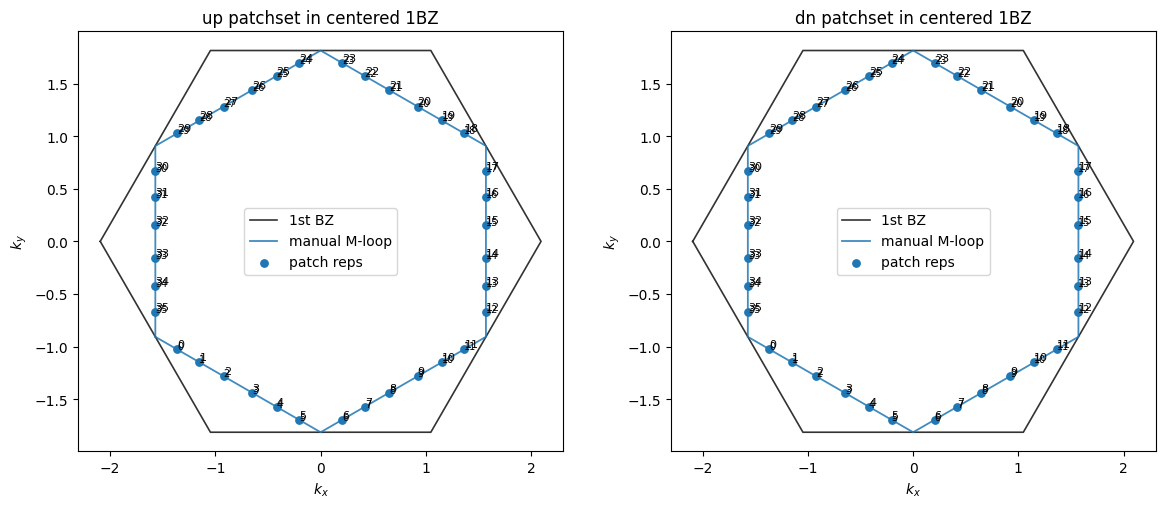

In [15]:
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1
model = KagomeNagaosa(dict(t=1.0, phi=0.0), spin=True, B=None)
# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 7           # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

PATCHSETS = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        # remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        # remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9
    ),
}

# ------------------------------------------------------------
# basic sanity: centered 1BZ patch plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    patching.plot_patchset(
        PATCHSETS[spin],
        ax=ax,
        show_contour=True,
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in PATCHSETS[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} patchset in centered 1BZ")

plt.tight_layout()
plt.show()


# Model

CASE = V_only  | U = 0.0  V = 20.0
T_START, T_STOP, NFREQ, NSTEPS = 15.0 0.05 50 600
NPATCH = 36
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 600
initial channel norm    = 39.93104274192105
solver.patch_measure_mode = length_over_vf_soft

=== bare (initial) sign-aware kernel metrics ===


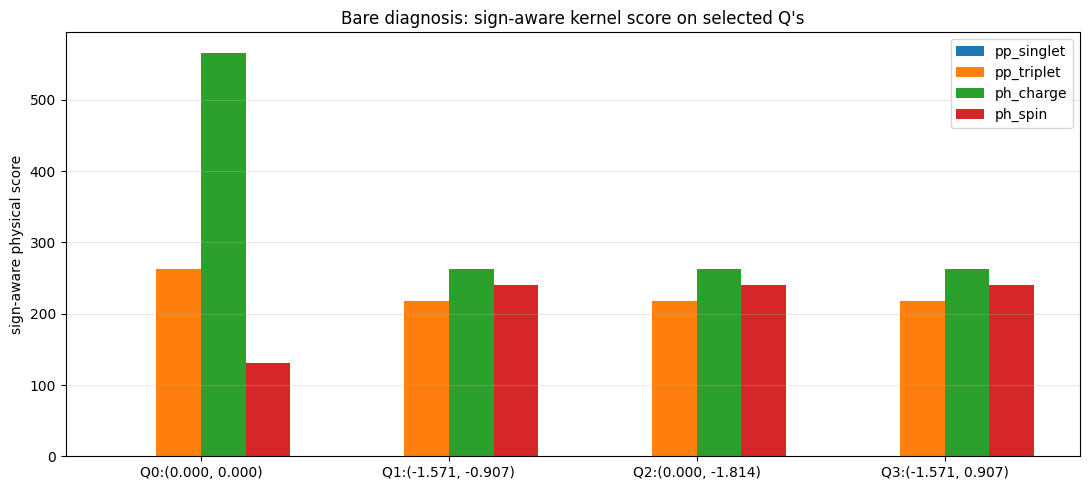


=== bare (initial) physical instability metrics ===


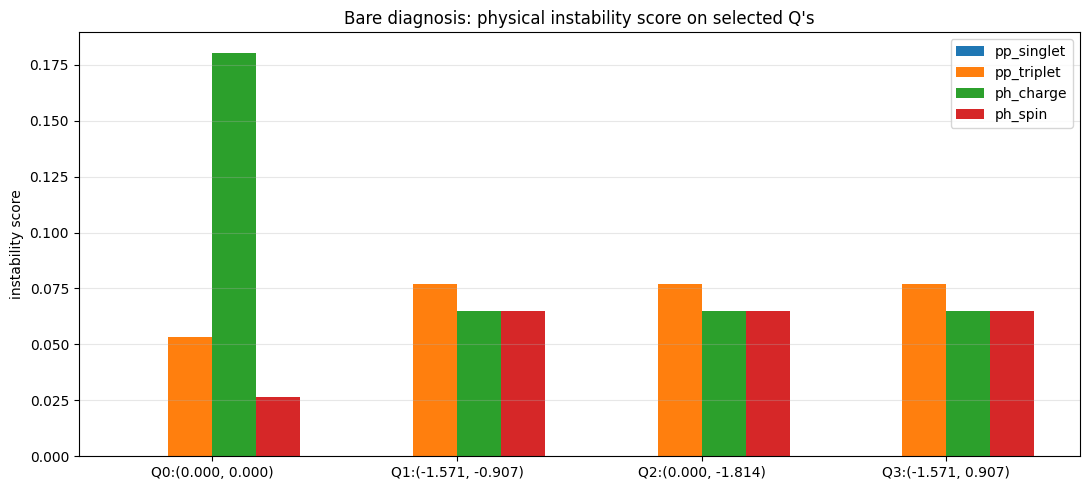

In [19]:
# ============================================================
# Choose interaction case
# ============================================================
CASE = "V_only"   # "U_only" or "V_only"

if CASE == "U_only":
    U_TEST, V_TEST = 10.0, 0.0
elif CASE == "V_only":
    U_TEST, V_TEST = 0.0, 20.0
else:
    raise ValueError("CASE must be 'U_only' or 'V_only'")


# ============================================================
# Basic diagnosis setup
# ============================================================
T_START = 15.0
T_STOP  = 0.05
NFREQ   = 50
NSTEPS  = 600

# Selected transfer momenta
M6 = patching.exact_M6_points_1bz(model)
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")


# ============================================================
# Build bare interaction + bare solver
# ============================================================
bare_int = interaction.BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = frg_flow.BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = frg_flow.FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,

    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # lenient integrator setup for exploration
    max_relative_update=5.0,
    min_substep_fraction=1.0 / 512.0,
    channel_divergence_threshold=2e2,

    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,
    diagnosis_landau_F=False,

    # current flow measure
    patch_measure_mode="length_over_vf_soft",              # change here later if needed
    patch_measure_soft_vf_eps=1e-8,
    patch_measure_normalize_mean=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())
print("solver.patch_measure_mode =", getattr(solver, "patch_measure_mode", None))

# ============================================================
# Bare sign-aware kernel metrics
# ============================================================
builder0 = build_builder_from_solver(solver, Landau_F=False)
df_signaware_bare, signaware_store = evaluate_signaware_selected_Qs(
    builder0,
    diagnosis_Qs,
    landau_F=False,
)

print("\n=== bare (initial) sign-aware kernel metrics ===")
# display(df_signaware_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_signaware_bare,
    value_col="physical_score",
    title="Bare diagnosis: sign-aware kernel score on selected Q's",
    ylabel="sign-aware physical score",
)

best_signaware_bare = leading_row_from_df(df_signaware_bare, "physical_score")
# print("\n=== bare sign-aware leader ===")
# print("channel :", best_signaware_bare["channel"])
# print("Q       :", fmt_q(best_signaware_bare["Q"], nd=6))
# print("score   :", f"{best_signaware_bare['physical_score']:.12e}")
# print("chosen  :", best_signaware_bare["chosen_sign"], f"{best_signaware_bare['chosen_eval']:.12e}")


# ============================================================
# Bare physical instability diagnosis
# ============================================================
df_instab_bare, instab_store = evaluate_instability_selected_Qs(
    builder0,
    solver,
    diagnosis_Qs,
    temperature=T_START,          # use initial T
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

print("\n=== bare (initial) physical instability metrics ===")
# display(df_instab_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_instab_bare,
    value_col="score",
    title="Bare diagnosis: physical instability score on selected Q's",
    ylabel="instability score",
)

best_instab_bare = leading_row_from_df(df_instab_bare, "score")
# print("\n=== bare physical-instability leader ===")
# print("channel :", best_instab_bare["channel"])
# print("Q       :", fmt_q(best_instab_bare["Q"], nd=6))
# print("score   :", f"{best_instab_bare['score']:.12e}")
# print("eval    :", f"{best_instab_bare['leading_eval']:.12e}")
# print("bubble  :", best_instab_bare["bubble_source"])
# print("proj    :", best_instab_bare["projection_name"])

# Flow

In [ ]:
# ============================================================
# Flow run parameters
# ============================================================
PRINT_EVERY = 5               # print every N steps
LAST_N_STEPS_TO_PLOT = 60     # None -> plot all; integer -> only last N steps
PLOT_YLOG = True

# physical instability diagnosis options
PH_BUBBLE_MODE = "patchrep"
PROJECT_PH_CHARGE_Q0_UNIFORM = True
PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT = False


print("\n================ RG FLOW START ================\n")

# history, signaware_history_df, instability_history_df, grouped_plot_df = run_flow_with_tracking(
#     solver,
#     diagnosis_Qs,
#     print_every=PRINT_EVERY,
#     ph_bubble_mode=PH_BUBBLE_MODE,
#     project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
#     project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
# )
history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots = run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    print_every=PRINT_EVERY,
    ph_bubble_mode=PH_BUBBLE_MODE,
    project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
    project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
)

print("\n================ RG FLOW DONE ================\n")
print("history length =", len(history))

last_rec = history[-1]
print("final step =", last_rec.step_index)
print("final T    =", last_rec.temperature)
print("final rhs_norm =", last_rec.rhs_norm)
print("final channel_norm =", last_rec.channel_norm)
print("instability =", last_rec.instability)
print("terminated_early =", last_rec.terminated_early)
print("instability_reason =", last_rec.instability_reason)
print("termination_reason =", last_rec.termination_reason)

# display(signaware_history_df.tail(12))
# display(instability_history_df.tail(12))

plot_flow_group_curves(
    grouped_plot_df,
    last_n_steps=LAST_N_STEPS_TO_PLOT,
    ylog=PLOT_YLOG,
    title_prefix=f"{CASE} | U={U_TEST}, V={V_TEST}",
    ylim=1e-2
)


================ RG FLOW START ================

step=   0 | T=15.000000 | rhs_norm=0.000e+00 | lead_kernel=ph_charge @ Q0:(0.000, 0.000) score=5.666e+02
kernel scores: pp_singlet=9.882e-30, pp_triplet=2.623e+02, ph_charge=5.666e+02, ph_spin=1.311e+02
    lead_instability=ph_charge @ Q0:(0.000, 0.000) score=1.804e-01
instability: pp_singlet=1.930e-33, pp_triplet=5.322e-02, ph_charge=1.804e-01, ph_spin=2.661e-02
step=   5 | T=14.875209 | rhs_norm=1.730e+01 | lead_kernel=ph_charge @ Q0:(0.000, 0.000) score=5.784e+02
kernel scores: pp_singlet=7.070e+00, pp_triplet=2.598e+02, ph_charge=5.784e+02, ph_spin=1.305e+02
    lead_instability=ph_charge @ Q0:(0.000, 0.000) score=1.873e-01
instability: pp_singlet=3.153e-03, pp_triplet=5.349e-02, ph_charge=1.873e-01, ph_spin=2.690e-02
step=  10 | T=14.750417 | rhs_norm=1.631e+01 | lead_kernel=ph_charge @ Q0:(0.000, 0.000) score=5.912e+02
kernel scores: pp_singlet=1.390e+01, pp_triplet=2.576e+02, ph_charge=5.912e+02, ph_spin=1.301e+02
    lead_instab

# Diagnosis

In [ ]:
# ============================================================
# Diagnose one flowed step
# ============================================================
STEP_SELECTOR = -2   # -1 last step, -2 second last, -3 third last, or exact step index

diagnosis_result = diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    step_selector=STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
)

# Optional: inspect the raw tables
# display(diagnosis_result["df_signaware"].sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(diagnosis_result["df_instability"].sort_values(["Q_index", "channel"]).reset_index(drop=True))

# Debug

## Patch Information

In [ ]:

# # ------------------------------------------------------------
# # print patch info: k, energy, vF, |vF|, l, l/|vF|
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     ps = patchsets[spin]
#     print(f"\n{'='*72}")
#     print(f"{spin} patchset summary")
#     print(f"{'='*72}")
#     print(f"Npatch            = {ps.Npatch}")
#     print(f"gauge_method      = {ps.gauge_method}")
#     print(f"gauge_loop_phase  = {ps.gauge_loop_phase:.12e}")
#     print()

#     for p in ps.patches:
#         print(
#             f"id={p.patch_id:2d} | "
#             f"k={np.round(p.k_cart, 8)} | "
#             f"k_red={np.round(p.k_red, 8)} | "
#             f"E={p.energy:+.12e} | "
#             f"vF={np.round(p.vF, 8)} | "
#             f"|vF|={p.vF_norm:.12e} | "
#             f"l={0.0 if p.fs_arc_length is None else p.fs_arc_length:.12e} | "
#             f"l/|vF|={0.0 if p.weight_length_over_vf is None else p.weight_length_over_vf:.12e}"
#         )

# # ------------------------------------------------------------
# # gauge smoothness / loop phase check
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)

#     ovs = []
#     for i in range(len(U)):
#         j = (i + 1) % len(U)
#         ovs.append(np.vdot(U[i], U[j]))
#     ovs = np.asarray(ovs, dtype=complex)

#     print(f"\n{'='*72}")
#     print(f"{spin} gauge smoothness check")
#     print(f"{'='*72}")
#     print("neighbor overlap abs =")
#     print(np.round(np.abs(ovs), 8))
#     print("neighbor overlap arg =")
#     print(np.round(np.angle(ovs), 8))

#     # loop closure overlap
#     if len(U) > 1:
#         loop_ov = np.vdot(U[-1], U[0])
#         print(f"last-first overlap abs = {abs(loop_ov):.12e}")
#         print(f"last-first overlap arg = {np.angle(loop_ov):.12e}")

#     # whether the stored loop phase is basically fixed
#     if abs(patchsets[spin].gauge_loop_phase) < 1e-8:
#         print("Gauge loop phase looks fixed: YES")
#     else:
#         print("Gauge loop phase looks fixed: NOT fully")

# # ------------------------------------------------------------
# # compact arrays for later reuse
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     ps = patchsets[spin]
#     print(f"\n{'='*72}")
#     print(f"{spin} compact arrays")
#     print(f"{'='*72}")
#     print("energies =")
#     print(np.array2string(ps.patch_energy, precision=10, suppress_small=False))
#     print("vF norms =")
#     print(np.array2string(ps.patch_vF_norm, precision=10, suppress_small=False))
#     print("arc lengths l =")
#     print(np.array2string(ps.patch_arc_length, precision=10, suppress_small=False))
#     print("l / |vF| =")
#     print(np.array2string(ps.patch_weight_length_over_vf, precision=10, suppress_small=False))

# # ------------------------------------------------------------
# # extra strict sanity checks
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     ps = patchsets[spin]
#     max_abs_E = np.max(np.abs(ps.patch_energy)) if ps.Npatch > 0 else 0.0
#     print(f"\n{spin}: max |E-mu| = {max_abs_E:.12e}")